<a href="https://colab.research.google.com/github/lavanya12159-gif/Corizo/blob/main/Ads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("rakeshrau/social-network-ads")
csv_file_path = os.path.join(path, 'Social_Network_Ads.csv')
df = pd.read_csv(csv_file_path)
df

Using Colab cache for faster access to the 'social-network-ads' dataset.


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df.drop(columns=['User ID', 'Purchased'])
y = df['Purchased']
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)


LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)


Accuracy: 0.8562
[[184  23]
 [ 23  90]]


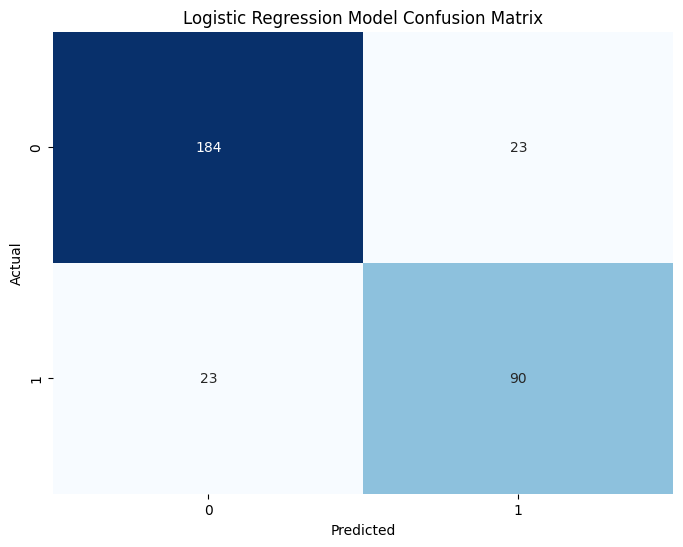

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.svm import SVC
classifier_svc = SVC()
classifier_svc.fit(X_train, y_train)

SVC()

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix
y_pred_svc = classifier_svc.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"SVC Model Accuracy: {accuracy_svc:.4f}")
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)
print(conf_matrix_svc)

SVC Model Accuracy: 0.8969
[[189  18]
 [ 15  98]]


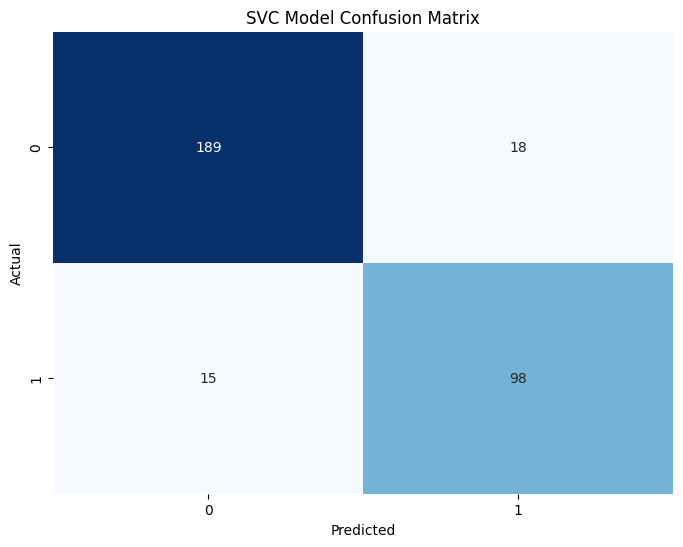

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svc, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVC Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Load the dataset (as 'df' was not defined in the previous execution)
path = kagglehub.dataset_download("rakeshrau/social-network-ads")
csv_file_path = os.path.join(path, 'Social_Network_Ads.csv')
df = pd.read_csv(csv_file_path)

# Prepare X and y, perform train-test split and scaling
X = df.drop(columns=['User ID', 'Purchased'])
y = df['Purchased']
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42) # Added random_state for reproducibility
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Instantiate a DecisionTreeClassifier
classifier_dt = DecisionTreeClassifier(random_state=42) # Added random_state for reproducibility

# Fit the classifier to the training data
classifier_dt.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully.")

100%|██████████| 3.27k/3.27k [00:00<00:00, 3.61MB/s]

Extracting files...
Decision Tree Classifier trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test set
y_pred_dt = classifier_dt.predict(X_test)

# Calculate and print the accuracy score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")

# Calculate and print the confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print(conf_matrix_dt)

Decision Tree Model Accuracy: 0.7594
[[171  31]
 [ 46  72]]


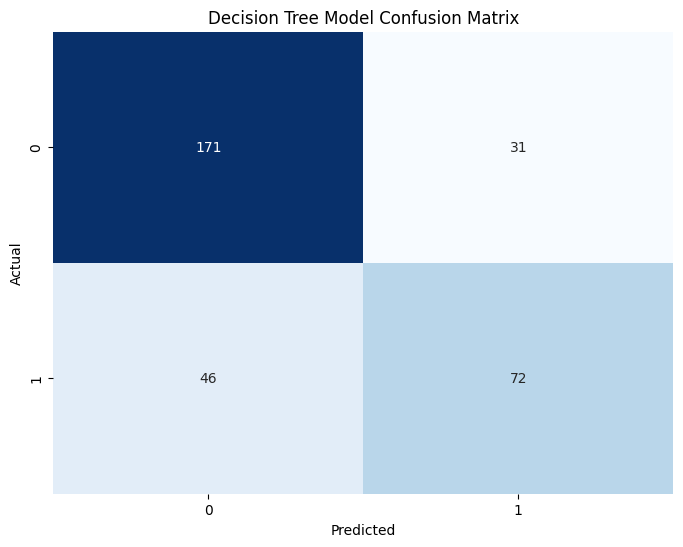

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Decision Tree Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier
classifier_rf = RandomForestClassifier(random_state=42) # Added random_state for reproducibility

# Fit the classifier to the training data
classifier_rf.fit(X_train, y_train)
print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test set
y_pred_rf = classifier_rf.predict(X_test)

# Calculate and print the accuracy score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")

# Calculate and print the confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print(conf_matrix_rf)

Random Forest Model Accuracy: 0.8375
[[189  13]
 [ 39  79]]


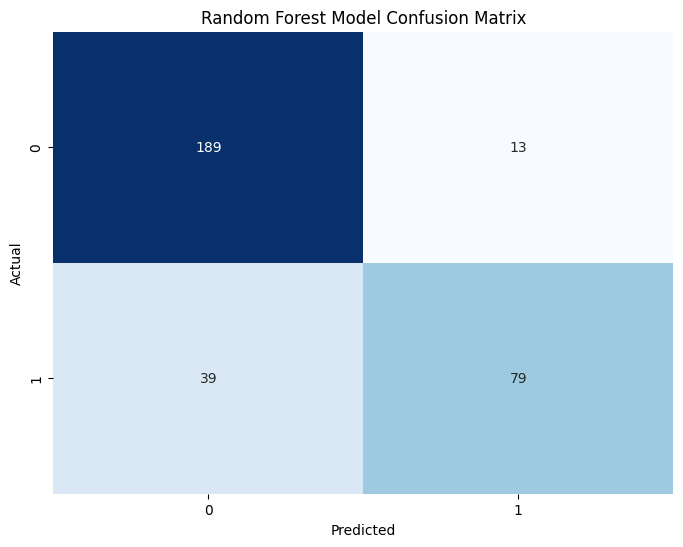

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()